In [1]:
%cd /home/maia-user/NeuroCBIR/
!ls

/home/maia-user/NeuroCBIR
 cbir			     preprocessing
 CBIR.ipynb		     README.md
 CBIR_wholeBrain.ipynb	     reports
 CBIR_wholeBrain_SVF.ipynb   seg_preparation.ipynb
 compute_SVF.ipynb	     subcortical_AE_training.ipynb
 data			    'subcortical_SVF_AE_training copy.ipynb'
 global_AE_training.ipynb   'subcortical_SVF_training .ipynb'
 global_SVF_training.ipynb   training
 model			     utils
 monai_test.ipynb


/usr/local/lib/python3.10/dist-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


In [2]:
import torch
import torch.nn as nn
import os
import pandas as pd
import nibabel as nib
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from torch.utils.data import DataLoader
from IPython.display import clear_output

seed = 42

(176, 208, 160) 1.0 0.0


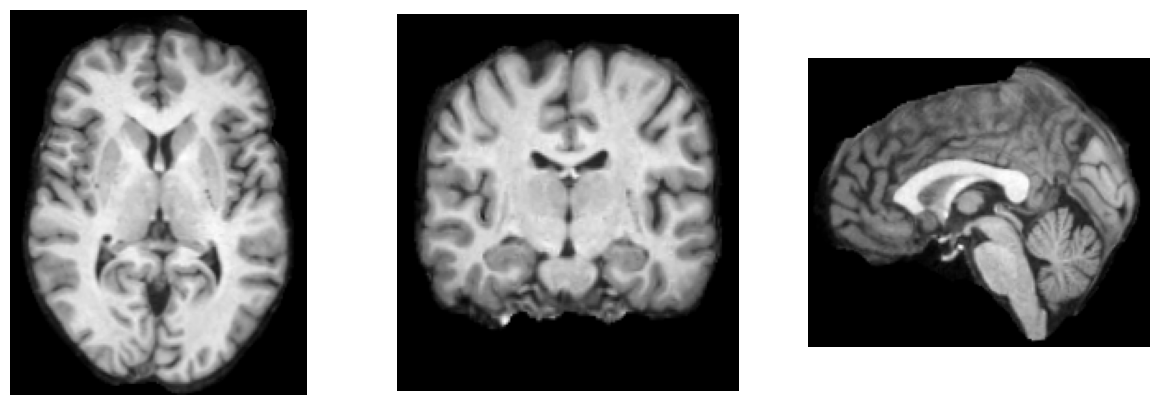

(192, 224, 160) 255 0


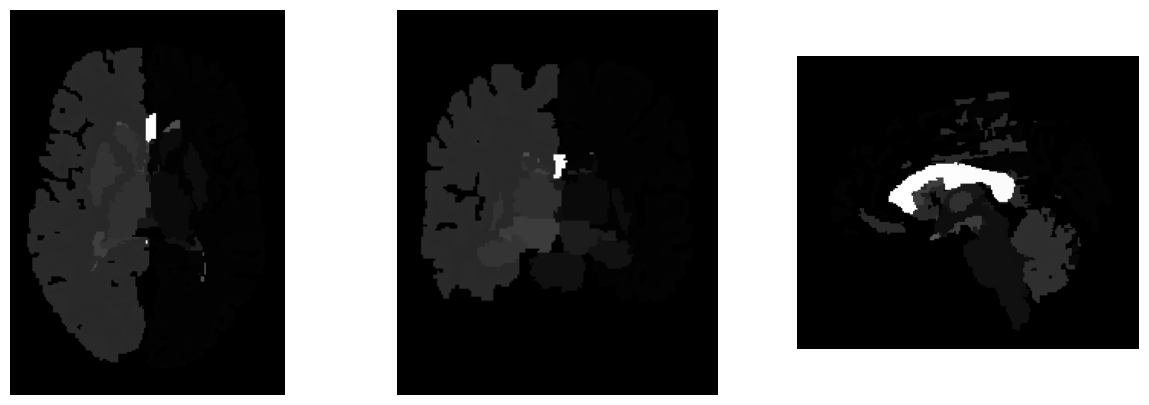

In [3]:
from preprocessing.padding import pad_mri_to_shape

# Load NIfTI file
img_seg = np.load(r"/home/maia-user/Dataset/OASIS3_NPY_UINT/OAS30001_MR_d0129.npy", allow_pickle=True).item()
mri_data = img_seg['image']
mri_data = mri_data.astype(np.float32) / 255.0
seg = img_seg['seg']

# nifti_img = nib.load(r"/home/maia-user/Dataset/OASIS3/T1w/OAS30001_MR_d2430/mri/align_norm+cropped.nii.gz")
# mri_data = nifti_img.get_fdata()

# Show a single slice (assuming 3D MRI data)
print(mri_data.shape, np.max(mri_data), np.min(mri_data))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(mri_data[mri_data.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(mri_data[:, mri_data.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(mri_data[:, :, mri_data.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()

# Show a single slice (assuming 3D MRI data)
seg = pad_mri_to_shape(seg, target_shape=(96*2, 112*2, 80*2))
print(seg.shape, np.max(seg), np.min(seg))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(seg[seg.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(seg[:, seg.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(seg[:, :, seg.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()



(96, 112, 80, 3) 5.027 -7.293


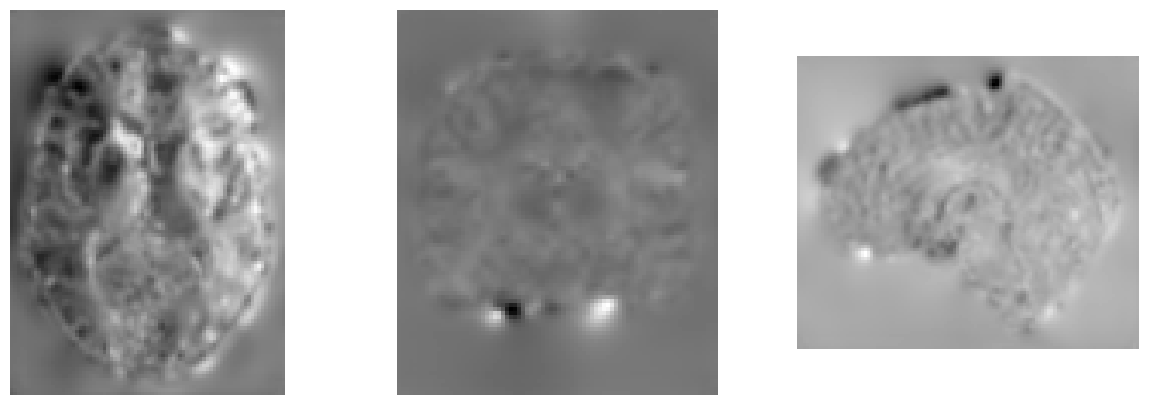

(96, 112, 80) 255 0


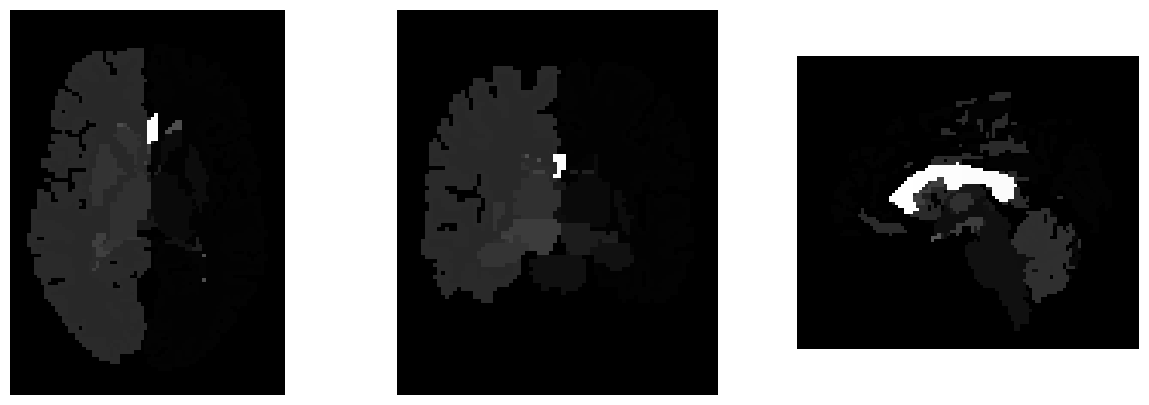

In [4]:
# Load NIfTI file
svf = np.load(r"/home/maia-user/Dataset/OASIS3_NPY_SVF/FROM__OAS30001_MR_d0129__TO__OAS30001_MR_d0757.npy")

# nifti_img = nib.load(r"/home/maia-user/Dataset/OASIS3/T1w/OAS30001_MR_d2430/mri/align_norm+cropped.nii.gz")
# mri_data = nifti_img.get_fdata()

# Show a single slice (assuming 3D MRI data)
print(svf.shape, np.max(svf), np.min(svf))
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(svf[svf.shape[0] // 2, : ,:, 0], cmap="gray")
axes[0].axis("off")
axes[1].imshow(svf[:, svf.shape[1] // 2, :, 1], cmap="gray")
axes[1].axis("off")
axes[2].imshow(svf[:, :, svf.shape[2] // 2, 2], cmap="gray")
axes[2].axis("off")
plt.show()

# Show a single slice (assuming 3D MRI data)
seg = pad_mri_to_shape(seg, target_shape=(96*2, 112*2, 80*2))[::2, ::2, ::2]
print(seg.shape, np.max(seg), np.min(seg))

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].imshow(seg[seg.shape[0] // 2, : ,:], cmap="gray")
axes[0].axis("off")
axes[1].imshow(seg[:, seg.shape[1] // 2, :], cmap="gray")
axes[1].axis("off")
axes[2].imshow(seg[:, :, seg.shape[2] // 2], cmap="gray")
axes[2].axis("off")
plt.show()


In [5]:
svf.shape

(96, 112, 80, 3)

In [6]:
from preprocessing.load_dataset import list_files_with_extension, BrainMRIDataset

# Loading MRI  paths
dataset_path = r"/home/maia-user/Dataset/OASIS3_NPY_SVF/"
file_paths, file_names = list_files_with_extension(dataset_path, extension=".npy")
raw_image_paths = np.array([os.path.join(dataset_path, file_path, file_name) for file_path, file_name in zip(file_paths, file_names)])
raw_image_ids = np.array([file_path.split('.')[0] for file_path in file_names])

# Load file with labels
labels_path = r"/home/maia-user/Dataset/OASIS3/OASIS3_UDSb4_cdr.xlsx"
labels_df = pd.read_excel(labels_path, sheet_name= 'Labels')


# Some recordings might be removed, i.e. nan labels
# Match svf and labels
raw_labels = np.array([labels_df[labels_df['OASIS_session_label'].apply(lambda x: pd.notna(x) and x in image_id)]['disease_label'].max()
                                for image_id in raw_image_ids]).astype('float32')

# Match svf and age dif
raw_ages_dif = np.array([labels_df[labels_df['OASIS_session_label'].apply(lambda x: pd.notna(x) and x in image_id)]['age_at_visit']
                                for image_id in raw_image_ids]).astype('float32')
raw_ages_dif = raw_ages_dif[:, 1] - raw_ages_dif[:, 0]

# Match svf and id
raw_ids = np.array([labels_df[labels_df['OASISID'].apply(lambda x: pd.notna(x) and x in image_id)]['OASISID'].unique()
                                for image_id in raw_image_ids]).flatten()

# For segmentatio
seg_folder = "/home/maia-user/Dataset/OASIS3_NPY_UINT/"
extension = ".npy"
raw_mri_svf_sessions = np.array([labels_df[labels_df['OASIS_session_label'].apply(lambda x: pd.notna(x) and x in image_id)]['OASIS_session_label'].values.flatten()
                         for image_id in raw_image_ids])
raw_mri_svf_sessions = np.array([[seg_folder + s1 + extension, seg_folder + s2 + extension] for s1, s2 in raw_mri_svf_sessions])


# Filtering out undesired cases
labels = raw_labels[~np.isnan(raw_labels)]
image_paths = raw_image_paths[~np.isnan(raw_labels)]
ages_dif = raw_ages_dif[~np.isnan(raw_labels)]
ids = raw_ids[~np.isnan(raw_labels)]
mri_svf_sessions = raw_mri_svf_sessions[~np.isnan(raw_labels)]

print(raw_labels.shape, labels.shape)
print(labels.shape, image_paths.shape, ages_dif.shape, ids.shape, mri_svf_sessions.shape)

/usr/local/lib/python3.10/dist-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


(2778,) (2778,)
(2778,) (2778,) (2778,) (2778,) (2778, 2)


In [7]:
from preprocessing.split_dataset import stratified_patient_split

# Longitudinal splitting dataset into training and testing sets
train_set, val_set, test_set = stratified_patient_split(image_paths=image_paths, labels=labels, ages_dif=ages_dif, ids=ids, mri_svf_sessions=mri_svf_sessions)

# Print dataset sizes
print(f"Training samples: {len(train_set['image_paths'])} - IR: {np.sum(train_set['labels'])/len(train_set['image_paths']):.2f}")
print(f"Validation samples: {len(val_set['image_paths'])} - IR: {np.sum(val_set['labels'])/len(val_set['image_paths']):.2f}")
print(f"Testing samples: {len(test_set['image_paths'])} - IR: {np.sum(test_set['labels'])/len(test_set['image_paths']):.2f}")

Training samples: 1931 - IR: 0.16
Validation samples: 345 - IR: 0.17
Testing samples: 502 - IR: 0.10


In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
from preprocessing.load_dataset import StratifiedBatchSampler, SubcorticalSVFDataset
import torchio as tio

batch_size = 20  # Make sure this is even!

augmentation_transforms = tio.Compose([
                                        # tio.RandomAffine(
                                        #     scales=(0.9, 1.05),        # Random scaling
                                        #     degrees=5,               # Random rotation in degrees
                                        #     translation=5            # Random translation in mm
                                        # ),
                                        tio.RandomNoise(mean=0.0, std=0.02),
                                        # tio.RandomFlip(axes=('LR',)),  # Random left-right flip
                                    ])


subcortical_fs_labels = {
    "Cortical white matter (lh)": 2,
    "Lateral Ventricle (lh)": 4,
    "Inferior Lateral Ventricle (lh)": 5,
    "Cerebellar White Matter (lh)": 7,
    "Cerebellar Cortex (lh)": 8,
    "Thalamus (lh)": 10,
    "Caudate (lh)": 11,
    "Putamen (lh)": 12,
    "Pallidum (lh)": 13,
    "3rd-Ventricle": 14,
    "4th-Ventricle": 15,
    "Brain Stem": 16,
    "Hippocampus (lh)": 17,
    "Amygdala (lh)": 18,
    "CSF": 24,
    "Accumbens (lh)": 26,
    "Ventral DC (lh)": 28,
    "Choroid Plexus (lh)": 31,
    "Cortical white matter (rh)": 41,
    "Lateral Ventricle (rh)": 43,
    "Inferior Lateral Ventricle (rh)": 44,
    "Cerebellar White Matter (rh)": 46,
    "Cerebellar Cortex (rh)": 47,
    "Thalamus (rh)": 49,
    "Caudate (rh)": 50,
    "Putamen (rh)": 51,
    "Pallidum (rh)": 52,
    "Hippocampus (rh)": 53,
    "Amygdala (rh)": 54,
    "Accumbens (rh)": 58,
    "Ventral DC (rh)": 60,
    "Choroid Plexus (rh)": 63,
    "WM-hypointensities": 77
}


# Preparing the dataset to feed the network
train_dataset = SubcorticalSVFDataset(train_set['image_paths'], train_set['ages_dif'], train_set['labels'], train_set['mri_svf_sessions'], sparse_path='./data/common_bounding_boxes.json')
train_sampler = StratifiedBatchSampler(train_dataset, batch_size)
train_loader = DataLoader(train_dataset, batch_sampler=train_sampler, pin_memory=True, num_workers=1)

val_dataset = SubcorticalSVFDataset(val_set['image_paths'], val_set['ages_dif'], val_set['labels'], val_set['mri_svf_sessions'], sparse_path='./data/common_bounding_boxes.json')
val_sampler = StratifiedBatchSampler(val_dataset, batch_size)
val_loader = DataLoader(val_dataset, batch_sampler=val_sampler, num_workers=1)

test_dataset = SubcorticalSVFDataset(test_set['image_paths'], test_set['ages_dif'], test_set['labels'], test_set['mri_svf_sessions'], sparse_path='./data/common_bounding_boxes.json')
test_sampler = StratifiedBatchSampler(test_dataset, batch_size)
test_loader = DataLoader(test_dataset, batch_sampler=test_sampler, num_workers=1)


In [10]:
train_dataset[0]['svf'].shape

torch.Size([10, 3, 40, 24, 32])

Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.6245117..0.42333984].
Clipping input data to the valid range for imshow with RGB data ([0..1] for floats or [0..255] for integers). Got range [-0.23132324..0.44262695].


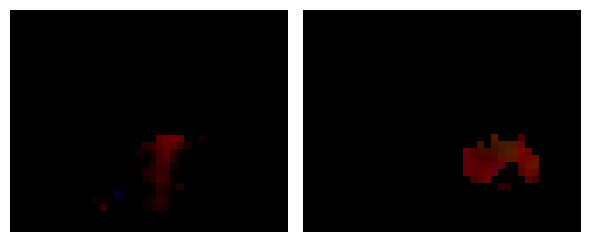

In [11]:
# Fetch one sample from the dataset
sample_1, sample_2 = train_dataset[0], train_dataset[-55]  # Get the first case

# Extract MRI image and mask
mri_image_1 = sample_1["svf"].squeeze().detach().cpu().numpy() # Remove channel dimension
mri_image_2 = sample_1["svf"].squeeze().detach().cpu().numpy() # Remove channel dimension

if len(mri_image_1.shape) > 3:
    subc_st_ind = -3
    mri_image_1 = mri_image_1[subc_st_ind]
    mri_image_2 = mri_image_2[subc_st_ind+1]

# Create a figure with 1 row and 3 columns
fig, axes = plt.subplots(1, 2, figsize=(6, 3))

# Load the image
axes[0].imshow(mri_image_1[:, :,  mri_image_1.shape[-1] // 2].T)
axes[0].axis('off')

axes[1].imshow(mri_image_2[:, :, mri_image_2.shape[-1] // 2].T)
axes[1].axis('off')

# Adjust layout to prevent overlap
plt.tight_layout()
# Display the plotS
plt.show()

In [12]:
sample_1["svf"].shape

torch.Size([10, 3, 40, 24, 32])

In [13]:
import torch
from model.autoencoder import Conv3DSparseAutoencoder
from torchsummary import summary

# Device setup
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Input size: [160, 176, 208]

# Initialize model and move it to the correct device
bottleneck_dim=64
input_shape = list(mri_image_1.shape)
autoencoder = Conv3DSparseAutoencoder(input_shape=input_shape, bottleneck_dim=bottleneck_dim).to(device)
# pretrained_param = torch.load('./data/pretrained_models/CP_sparseautoencoder_3d.pth')
# autoencoder.load_state_dict(pretrained_param)

# Keep only matching keys (ignore fully connected layers)
# pretrained_dict = pretrained_param
# new_model_dict = autoencoder.state_dict()
# pretrained_dict = {k: v for k, v in pretrained_dict.items() if k in new_model_dict}
# # Load weights into the new model
# new_model_dict.update(pretrained_dict)
# autoencoder.load_state_dict(new_model_dict)

# Run summary — torchsummary will match the device of the model
_=summary(autoencoder, input_shape)


Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 16, 5, 3, 4]         --
|    └─Sequential: 2-1                   [-1, 64, 20, 12, 16]      --
|    |    └─Conv3d: 3-1                  [-1, 64, 20, 12, 16]      12,352
|    |    └─GroupNorm: 3-2               [-1, 64, 20, 12, 16]      128
|    |    └─ReLU: 3-3                    [-1, 64, 20, 12, 16]      --
|    |    └─Dropout3d: 3-4               [-1, 64, 20, 12, 16]      --
|    └─Sequential: 2-2                   [-1, 32, 10, 6, 8]        --
|    |    └─Conv3d: 3-5                  [-1, 32, 10, 6, 8]        131,104
|    |    └─GroupNorm: 3-6               [-1, 32, 10, 6, 8]        64
|    |    └─ReLU: 3-7                    [-1, 32, 10, 6, 8]        --
|    |    └─Dropout3d: 3-8               [-1, 32, 10, 6, 8]        --
|    └─Sequential: 2-3                   [-1, 16, 5, 3, 4]         --
|    |    └─Conv3d: 3-9                  [-1, 16, 5, 3, 4]         32,784
|

In [14]:
# Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

lr = 1e-3
epochs = 50000

decay, no_decay = [], []
for name, param in autoencoder.named_parameters():
    if param.requires_grad:
        if name.endswith("bias") or "bn" in name.lower():
            no_decay.append(param)
        else:
            decay.append(param)

weight_decay = 1e-4
optimizer = torch.optim.AdamW([
    {'params': decay, 'weight_decay': weight_decay},
    {'params': no_decay, 'weight_decay': 0.0}
], lr=1e-3)

criterion = nn.MSELoss()

In [15]:
from training.report_writer import TrainingReport
from training.train_SVF import train

# Initialize report
report = TrainingReport(autoencoder,
                        input_shape=input_shape, 
                        dataset_info={"N_train": len(train_dataset), 
                                      "IR_train": np.sum(train_set['labels'])/len(train_set['image_paths']),
                                      "N_val": len(val_dataset), 
                                      "IR_val": np.sum(val_set['labels'])/len(val_set['image_paths']),
                                      "N_test": len(test_dataset), 
                                      "IR_test": np.sum(test_set['labels'])/len(test_set['image_paths']),
                                      "batch_size": batch_size}, 
                        optimizer=optimizer, 
                        lr=lr, 
                        weight_decay=weight_decay, 
                        report_dir="reports/logs"
)


Layer (type:depth-idx)                   Output Shape              Param #
├─Sequential: 1-1                        [-1, 16, 5, 3, 4]         --
|    └─Sequential: 2-1                   [-1, 64, 20, 12, 16]      --
|    |    └─Conv3d: 3-1                  [-1, 64, 20, 12, 16]      12,352
|    |    └─GroupNorm: 3-2               [-1, 64, 20, 12, 16]      128
|    |    └─ReLU: 3-3                    [-1, 64, 20, 12, 16]      --
|    |    └─Dropout3d: 3-4               [-1, 64, 20, 12, 16]      --
|    └─Sequential: 2-2                   [-1, 32, 10, 6, 8]        --
|    |    └─Conv3d: 3-5                  [-1, 32, 10, 6, 8]        131,104
|    |    └─GroupNorm: 3-6               [-1, 32, 10, 6, 8]        64
|    |    └─ReLU: 3-7                    [-1, 32, 10, 6, 8]        --
|    |    └─Dropout3d: 3-8               [-1, 32, 10, 6, 8]        --
|    └─Sequential: 2-3                   [-1, 16, 5, 3, 4]         --
|    |    └─Conv3d: 3-9                  [-1, 16, 5, 3, 4]         32,784
|

In [16]:

train_losses, val_losses = train(autoencoder, train_loader, val_loader, optimizer, criterion, device, max_epochs=500, patience=15, report=report)

Epoch 1 - Training:   1%|          | 6/807 [00:08<19:59,  1.50s/it]


KeyboardInterrupt: 

In [ ]:
dataset = BrainMRIDataset(image_paths, ages, labels,
                          transform=None, transform_age=3, cache=False, sparse_path='./data/common_bounding_boxes.json')

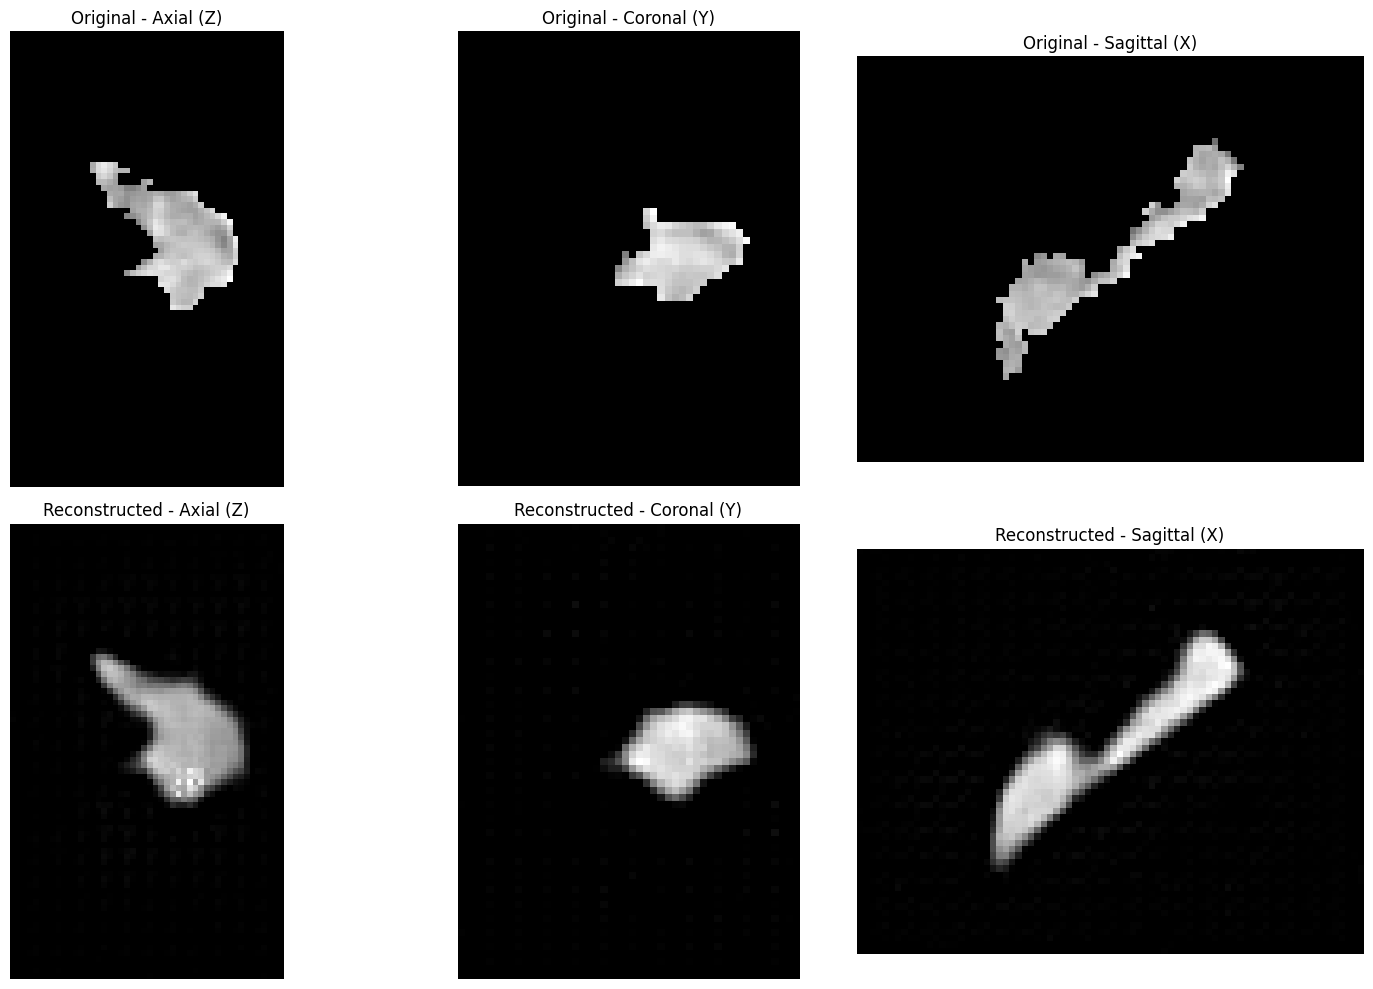

In [ ]:
import torch
import matplotlib.pyplot as plt
import numpy as np

sample_1 = dataset[699]  # Any sample

autoencoder.eval()

with torch.no_grad():
    subc_struc_ind = 0
    input_img = sample_1["input"].unsqueeze(0).to(device, dtype=torch.float32)[0:1, subc_struc_ind:subc_struc_ind+1]
    z, reconstructed = autoencoder(input_img)

# Convert to NumPy
original_np = input_img.squeeze().cpu().numpy()
reconstructed_np = reconstructed.squeeze().cpu().numpy()

# Compute mid-slices
pz = original_np.shape[0] // 2  # Axial
py = original_np.shape[1] // 2  # Coronal
px = original_np.shape[2] // 2  # Sagittal

# Extract slices
slices = {
    "Axial (Z)":      (original_np[pz, :, :], reconstructed_np[pz, :, :]),
    "Coronal (Y)":    (original_np[:, py, :], reconstructed_np[:, py, :]),
    "Sagittal (X)":   (original_np[:, :, px], reconstructed_np[:, :, px]),
}

# Plotting
fig, axes = plt.subplots(2, 3, figsize=(15, 10))

for i, (title, (orig, recon)) in enumerate(slices.items()):
    axes[0, i].imshow(orig, cmap='gray')
    axes[0, i].set_title(f'Original - {title}')
    axes[0, i].axis('off')

    axes[1, i].imshow(recon, cmap='gray')
    axes[1, i].set_title(f'Reconstructed - {title}')
    axes[1, i].axis('off')

plt.tight_layout()
plt.show()


In [ ]:
import torch
import numpy as np
from tqdm import tqdm

def extract_whole_image_features(autoencoder, dataset, device="cuda", subject_ids=None, record_ids=None, dementia_subcortical_indices=None):
    if not dementia_subcortical_indices:
        dementia_subcortical_indices = {
                    "Hippocampus (lh)": 17, "Hippocampus (rh)": 53, "Amygdala (lh)": 18, "Amygdala (rh)": 54, "Thalamus (lh)": 10,
                    "Thalamus (rh)": 49, "Caudate (lh)": 11, "Caudate (rh)": 50, "Putamen (lh)": 12, "Putamen (rh)": 51,
                }

    autoencoder.to(device)
    autoencoder.eval()
    data = []

    for idx in tqdm(range(len(dataset)), desc="Extracting features"):
        for ss_idx, (key, _) in enumerate(dementia_subcortical_indices.items()):
            if record_ids is not None:
                record_id = record_ids[idx]

            if subject_ids is not None:
                subject_id = subject_ids[idx]
                
            sample = dataset[idx]
            img = sample["input"].unsqueeze(0).to(device, dtype=torch.float32)[0:1, ss_idx:ss_idx+1]
            
            with torch.no_grad():
                z, _ = autoencoder(img)
            
            data.append({
                "subject_id": subject_id,
                "record_id": record_id,
                "subc_str": key,
                "label": sample["label"].item(),
                "age": sample["age"].item(),
                "features": z.view(-1).cpu().numpy(),
            })
        
    return data

record_ids = [im_path.split("/")[-1].split(".")[0] for im_path in image_paths]

t = -1
dataset = BrainMRIDataset(image_paths[0:t], ages[0:t], labels[0:t],
                          transform=None, transform_age=None, cache=False, sparse_path='./data/common_bounding_boxes.json')
dataset_feats = extract_whole_image_features(autoencoder, dataset, device="cpu", record_ids=record_ids[0:t], subject_ids=ids[0:t])

np.save(f"./data/dataset_feats_{report.timestamp}.npy", dataset_feats)

Extracting features: 100%|██████████| 2679/2679 [18:50<00:00,  2.37it/s]


In [ ]:
# np.save("./data/dataset_feats.npy", dataset_feats)

In [ ]:
pd.DataFrame(dataset_feats)

,subject_id,record_id,subc_str,label,age,features
0,OAS30647,OAS30647_MR_d0232,Hippocampus (lh),0.0,55.165615,"[3.0249555, -3.566051, -1.4843479, 1.5621015, ..."
1,OAS30647,OAS30647_MR_d0232,Hippocampus (rh),0.0,55.165615,"[-2.0236418, -4.8120666, -0.34693757, -1.34476..."
2,OAS30647,OAS30647_MR_d0232,Amygdala (lh),0.0,55.165615,"[-0.88457066, 0.13977386, -0.93993413, -1.3824..."
3,OAS30647,OAS30647_MR_d0232,Amygdala (rh),0.0,55.165615,"[1.8361444, 2.3839726, -2.6833372, 1.0424763, ..."
4,OAS30647,OAS30647_MR_d0232,Thalamus (lh),0.0,55.165615,"[-0.1933884, -1.0193717, 0.6264281, -0.7820382..."
...,...,...,...,...,...,...
495,OAS30249,OAS30249_MR_d1238,Thalamus (rh),0.0,54.211781,"[-1.9894514, 0.59194374, 1.8113632, 1.6918331,..."
496,OAS30249,OAS30249_MR_d1238,Caudate (lh),0.0,54.211781,"[1.3172529, -0.9376943, -1.2662104, 0.7693468,..."
497,OAS30249,OAS30249_MR_d1238,Caudate (rh),0.0,54.211781,"[-2.390715, -0.15084909, -4.908086, -1.176034,..."
498,OAS30249,OAS30249_MR_d1238,Putamen (lh),0.0,54.211781,"[1.1038939, -0.15658961, -0.6749717, -2.487439..."


In [ ]:
import gc

process = psutil.Process(os.getpid())
print(f"RAM used: {process.memory_info().rss / 1024 ** 2:.2f} MB")
gc.collect()
torch.cuda.empty_cache()
process = psutil.Process(os.getpid())
print(f"RAM used: {process.memory_info().rss / 1024 ** 2:.2f} MB")

RAM used: 4235.94 MB
RAM used: 4235.94 MB


In [ ]:
record_ids

['OAS30647_MR_d0232',
 'OAS31405_MR_d0149',
 'OAS30901_MR_d0155',
 'OAS30534_MR_d3728',
 'OAS30120_MR_d0784',
 'OAS30947_MR_d1688',
 'OAS30750_MR_d0894',
 'OAS30263_MR_d2483',
 'OAS31415_MR_d0070',
 'OAS30929_MR_d0115',
 'OAS31014_MR_d2235',
 'OAS30219_MR_d1184',
 'OAS30060_MR_d0074',
 'OAS30408_MR_d1193',
 'OAS30590_MR_d0095',
 'OAS30996_MR_d5818',
 'OAS30632_MR_d0106',
 'OAS31114_MR_d4375',
 'OAS31446_MR_d0070',
 'OAS31462_MR_d0107',
 'OAS30754_MR_d0019',
 'OAS30908_MR_d0617',
 'OAS30514_MR_d1526',
 'OAS30908_MR_d0065',
 'OAS30808_MR_d0498',
 'OAS30178_MR_d1384',
 'OAS30182_MR_d1397',
 'OAS31014_MR_d3555',
 'OAS30848_MR_d0070',
 'OAS31440_MR_d0040',
 'OAS30443_MR_d2432',
 'OAS31005_MR_d0066',
 'OAS30532_MR_d0047',
 'OAS30185_MR_d6000',
 'OAS30732_MR_d0074',
 'OAS30376_MR_d0082',
 'OAS30729_MR_d4384',
 'OAS30909_MR_d0109',
 'OAS30048_MR_d2292',
 'OAS30119_MR_d3722',
 'OAS30731_MR_d3375',
 'OAS31338_MR_d0120',
 'OAS30869_MR_d0077',
 'OAS30726_MR_d0061',
 'OAS30502_MR_d0395',
 'OAS30445